
# Categorical Ensemble Spatial Interpolation (Categorical ESI)
<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

## What Is Categorical ESI?

**Categorical ESI** (`spatialize.gs.cat_esi`) applies the same ensemble machinery as [Ensemble Spatial Interpolation (ESI)](../introductory/esi_overview.ipynb) to *discrete labels* — soil type, land-cover class, lithology, an ordinal quality grade — by swapping the local interpolator for a local **classifier** trained inside each partition cell, and swapping the aggregation mean for a **majority vote** (or, for ordinal categories, a **median vote**).

Concretely, `cat_esi_griddata`/`cat_esi_nongriddata` mirror `esi_griddata`/`esi_nongriddata` argument-for-argument: `n_partitions`, `alpha`, `seed`, `best_params_found`, and hyperparameter search all work the same way. The two differences are:

- **`classifier`** replaces `local_interpolator` — the default `"knn_pca"` is a custom anisotropic PCA+KNN classifier tuned per cell; `"knn"`, `"svm"`, `"rf"`, `"dt"`, and a generic `"scikit-learn"` wrapper are also available.
- **`agg_function`/`ordinal_order`** replace the continuous aggregation function — `'mv'` performs nominal majority vote by default, or ordinal median vote once an `ordinal_order` (e.g. `{"Low": 0, "Medium": 1, "High": 2}`) is supplied.

As with continuous ESI, disagreement across the ensemble's partitions doubles as a natural, per-location **precision** map — here measured as the fraction of partitions whose predicted label disagrees with the final vote, rather than a numeric spread.

## Usage Examples
### Setup

This notebook uses `spatialize.evaluation.SyntheticScenario(categorical=True)` to generate synthetic nominal and ordinal ground truths with deliberately irregular, non-convex class boundaries — hard enough to make the ensemble's advantage over a single global classifier visible.

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from spatialize.gs.cat_esi import cat_esi_griddata, cat_esi_hparams_search
from spatialize.evaluation import SyntheticScenario, accuracy, f1_score

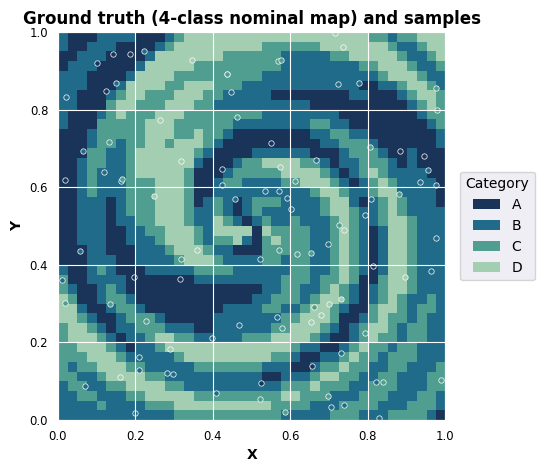

In [3]:
# Generating a Synthetic Nominal Scenario
scenario = SyntheticScenario(categorical=True, n_grid_points=40, griddata=True)
points, values, xi, reference_values = scenario.simulate_scenario(
    kind='nominal', n_samples=100, seed=0)

scenario.plot_2d_scenario(points, values, xi, reference_values, theme='darkgrid',
                          title='Ground truth (4-class nominal map) and samples')
plt.show()

### Running Categorical ESI

`cat_esi_hparams_search` runs k-fold cross-validation over a grid of `n_partitions`, `alpha`, and classifier-specific parameters, scored here by macro-F1. `.best_result()` returns a dict ready to feed into `best_params_found`.

In [5]:
search_result = cat_esi_hparams_search(points, values, xi,
                                       classifier="knn_pca",
                                       scoring="f1_macro",
                                       n_partitions=[100],
                                       alpha=[0.7, 0.8, 0.9],
                                       n_neighbors=[3, 5],
                                       k=3, seed=42, folding_seed=42)
best_params = search_result.best_result()
best_params

finished 100% of 6 iterations ... 

done (elapsed time: 35s)


{'cv_error': 0.7373354174129192,
 'classifier': 'knn_pca',
 'alpha': 0.7,
 'max_points': None,
 'n_cv_splits': None,
 'n_neighbors': 3,
 'n_partitions': 100,
 'result_data_index': 0,
 'agg_function': 'mv',
 'ordinal_order': None,
 'seed': 42}

finished 100% of 200 iterations ... 

done (elapsed time:  2s)
finished 100% of 200 iterations ... 

done (elapsed time:  1s)


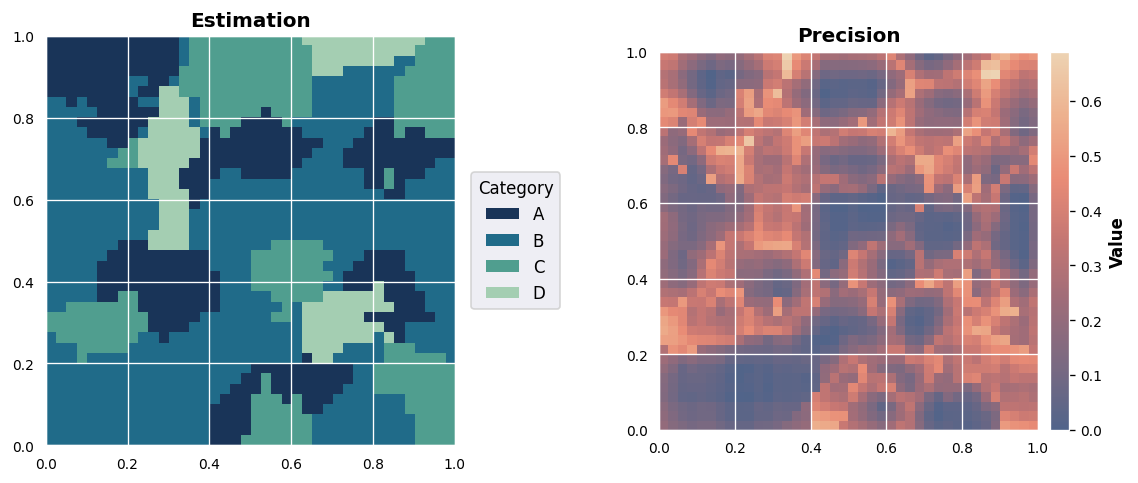

In [6]:
result_nominal = cat_esi_griddata(points, values, xi,
                                  classifier="knn_pca",
                                  n_partitions=200,
                                  best_params_found=best_params)
result_nominal.quick_plot(figsize=(11, 5), theme='darkgrid')

`quick_plot()` shows the aggregated estimation next to its precision map: cells where the ensemble's partitions disagree cluster near the true, irregular class boundaries.

#### Comparison with a Global Baseline Classifier

To see what the ensemble actually buys over a single classifier, fit one plain `KNeighborsClassifier` on all training points with no spatial partitioning at all, and compare against the same reference grid.

In [7]:
baseline_knn = KNeighborsClassifier(n_neighbors=5).fit(points, values)
xi_flat = np.column_stack([xi[0].ravel(), xi[1].ravel()])
baseline_pred = baseline_knn.predict(xi_flat).reshape(reference_values.shape)

acc_esi = accuracy(reference_values.ravel(), result_nominal.estimation().ravel())
acc_base = accuracy(reference_values.ravel(), baseline_pred.ravel())
f1_esi = f1_score(reference_values.ravel(), result_nominal.estimation().ravel(), average='macro')
f1_base = f1_score(reference_values.ravel(), baseline_pred.ravel(), average='macro')

print(f"Categorical ESI — accuracy: {acc_esi:.3f}, macro-F1: {f1_esi:.3f}")
print(f"Global KNN      — accuracy: {acc_base:.3f}, macro-F1: {f1_base:.3f}")

Categorical ESI — accuracy: 0.411, macro-F1: 0.389
Global KNN      — accuracy: 0.388, macro-F1: 0.343


The global classifier has no notion of local uncertainty at all — it cannot flag *where* it is likely wrong. The ESI ensemble's `.precision()` map is the piece the baseline can never produce, regardless of how its raw accuracy compares.

### Ordinal Categorical ESI

When categories have a natural order (e.g. `Low < Medium < High`), majority vote can pick a class that "jumps" past the true rank in an ambiguous cell, while a **median vote** over the same partition predictions always lands on a category consistent with the ranking. `SyntheticScenario(categorical=True).simulate_scenario(kind='ordinal', ...)` builds a 3-class terrain field thresholded at balanced quantiles for exactly this purpose.

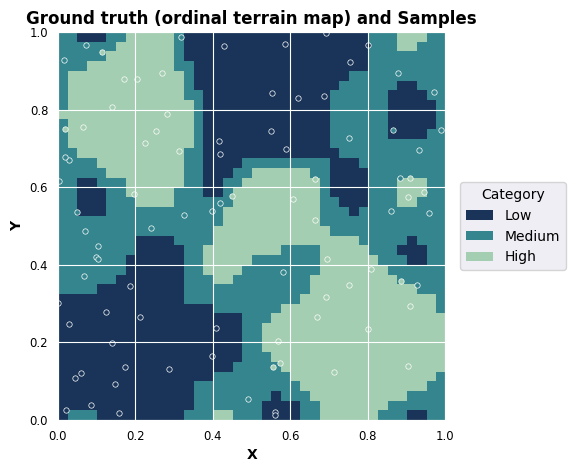

In [9]:
ORDER = SyntheticScenario.ORDINAL_ORDER  # {'Low': 0, 'Medium': 1, 'High': 2}

ordinal_scenario = SyntheticScenario(categorical=True, n_grid_points=40, griddata=True)
o_points, o_values, o_xi, o_reference = ordinal_scenario.simulate_scenario(
    kind='ordinal', n_samples=90, seed=1)

ordinal_scenario.plot_2d_scenario(o_points, o_values, o_xi, o_reference,
                                  nonnum_order=list(ORDER), theme='darkgrid',
                                  title='Ground truth (ordinal terrain map) and Samples')
plt.show()

Run the ensemble once, then re-aggregate the *same* ESI samples both ways — `re_estimate()` re-applies an aggregation function to the stored per-partition predictions without recomputing the ensemble, so the ordinal comparison costs nothing beyond the original run:

In [10]:
result_ordinal = cat_esi_griddata(o_points, o_values, o_xi,
                                  classifier="knn_pca", n_partitions=150, alpha=0.8, seed=7)

# capture the nominal majority-vote result before re_estimate() mutates it in place
nominal_mv_estimation = result_ordinal.estimation().copy()
nominal_mv_precision = result_ordinal.precision().copy()

result_ordinal.set_ordinal_order(ORDER)
ordinal_mv_estimation = result_ordinal.re_estimate('mv')
ordinal_mv_precision = result_ordinal.precision()

acc_nom_mv = accuracy(o_reference.ravel(), nominal_mv_estimation.ravel())
acc_ord_mv = accuracy(o_reference.ravel(), ordinal_mv_estimation.ravel())
print(f"Nominal majority vote — accuracy: {acc_nom_mv:.3f}")
print(f"Ordinal median vote   — accuracy: {acc_ord_mv:.3f}")

finished 100% of 150 iterations ... 

done (elapsed time:  3s)
finished 100% of 150 iterations ... 

done (elapsed time:  0s)
Nominal majority vote — accuracy: 0.764
Ordinal median vote   — accuracy: 0.765


`set_ordinal_order()` returns `self` (fluent) and `re_estimate('mv')` overwrites `result_ordinal`'s estimation and clears its cached precision, so the nominal-vote arrays must be captured beforehand if both are needed. Overall accuracy is close between the two here because splits are rare in this scenario; the ordinal variant's real guarantee is that whenever the ensemble *is* split, its vote never skips past an intermediate class the way majority vote occasionally can.

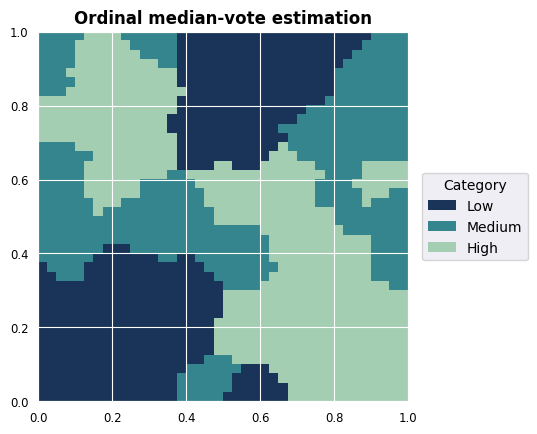

In [11]:
result_ordinal.plot_estimation(nonnum_order=list(ORDER), title='Ordinal median-vote estimation', theme='darkgrid')
plt.show()

::: {.callout-note icon=false}

### Advanced: Beyond Majority Vote

`spatialize.gs.cat_esi` also ships an optional Bayesian Truth Discovery (Dawid-Skene EM) aggregation, `aggregate_with_btd` / `result.re_estimate('btd')`, which treats each partition as a noisy "voter" and can incorporate spatial-smoothness constraints between adjacent categories. It requires an optionally-compiled C++ extension and is not demonstrated here — see the function's docstring in `spatialize.gs.cat_esi.agg_functions` if your install has it available.
:::

## Quantitative Performance Metrics

In [12]:
metrics_table = pd.DataFrame([
    {"Scenario": "Nominal", "Method": "Categorical ESI (knn_pca)",
     "Accuracy": acc_esi, "Macro F1": f1_esi,
     "Mean Precision": np.mean(result_nominal.precision())},
    {"Scenario": "Nominal", "Method": "Global KNN baseline",
     "Accuracy": acc_base, "Macro F1": f1_base,
     "Mean Precision": np.nan},
    {"Scenario": "Ordinal", "Method": "Categorical ESI — nominal mv",
     "Accuracy": acc_nom_mv,
     "Macro F1": f1_score(o_reference.ravel(), nominal_mv_estimation.ravel(), average='macro'),
     "Mean Precision": np.mean(nominal_mv_precision)},
    {"Scenario": "Ordinal", "Method": "Categorical ESI — ordinal mv",
     "Accuracy": acc_ord_mv,
     "Macro F1": f1_score(o_reference.ravel(), ordinal_mv_estimation.ravel(), average='macro'),
     "Mean Precision": np.mean(ordinal_mv_precision)},
])
metrics_table

,Scenario,Method,Accuracy,Macro F1,Mean Precision
0,Nominal,Categorical ESI (knn_pca),0.410625,0.388968,0.234972
1,Nominal,Global KNN baseline,0.388125,0.342910,NaN
2,Ordinal,Categorical ESI — nominal mv,0.764375,0.763008,0.145613
3,Ordinal,Categorical ESI — ordinal mv,0.765000,0.763713,0.145617


**Note**: The `Mean Precision` column is only defined for the ESI ensemble — the global baseline has no per-location uncertainty measure to report, hence the `NaN`.